In [19]:
pip install scikit-learn imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn]1/2 [imbalanced-learn]
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import glob
import os
import pickle
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [14]:
def parse_zeek_log(filepath):
    fields = None
    types = None

    with open(filepath) as f:
        for line in f:
            if line.startswith("#fields"):
                fields = line.strip().split("\t")[1:]
            elif line.startswith("#types"):
                types = line.strip().split("\t")[1:]
            elif not line.startswith("#"):
                break

    df = pd.read_csv(
        filepath,
        sep="\t",
        comment="#",
        names=fields,
        engine="python",
        na_values=["-", "(empty)"]
    )

    if "tunnel_parents   label   detailed-label" in df.columns:
     last = df["tunnel_parents   label   detailed-label"].astype(str)

     if last.str.contains("Benign|Malicious").any():
        split_cols = last.str.rsplit("   ", n=2, expand=True)

        df["tunnel_parents"] = split_cols[0]
        df["label"] = split_cols[1]
        df["detailed-label"] = split_cols[2]
    df.drop(columns=["tunnel_parents   label   detailed-label"], inplace=True)

    return df

In [3]:
directory_path = "./Malware"
all_dfs = []

for filepath in glob.glob(os.path.join(directory_path, '*.train')):
    print(f"Loading log: {filepath}")
    df = parse_zeek_log(filepath)
    all_dfs.append(df)

df_full = pd.concat(all_dfs)

Loading log: ./Malware/conn-1-1.log.train
Loading log: ./Malware/conn-60-1.log.train
Loading log: ./Malware/conn-3-1.log.train
Loading log: ./Malware/conn-34-1.log.train


In [4]:
df_full.to_csv('raw_data_concat.csv')

In [11]:
df = pd.read_csv('raw_data_concat.csv')

/tmp/ipykernel_12315/4206077921.py:1: DtypeWarning: Columns (0: service) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('raw_data_concat.csv')


## Preprocessing

In [7]:
# function untuk memudahkan hidup

def preprocess_data(df):
    for col in df.columns:
        if df[col].dtype == "float64":
            df[col] = df[col].fillna(0)
        else:
            df[col] = df[col].fillna("unknown")

    df["id.orig_p"] = df["id.orig_p"].astype(int)
    df["id.resp_p"] = df["id.resp_p"].astype(int)
    df["local_orig"] = df["local_orig"].astype(int)
    df["local_resp"] = df["local_resp"].astype(int)
    df = df[df["duration"] >= 0]
    df = df[df["orig_bytes"] >= 0]
    df['label'] = df['label'].map({'Malicious': 1, 'Benign': 0}).astype('category')
    df["ts"] = pd.to_datetime(df["ts"], unit="s")

    df["bytes_total"] = df["orig_bytes"] + df["resp_bytes"]
    df["bytes_ratio"] = df["orig_bytes"] / (df["resp_bytes"] + 1)
    df["pkts_total"] = df["orig_pkts"] + df["resp_pkts"]
    df["bytes_per_pkt"] = df["bytes_total"] / (df["pkts_total"] + 1)
    df["flow_rate"] = df["bytes_total"] / (df["duration"] + 1e-6)
    df["pkt_ratio"] = df["orig_pkts"] / (df["resp_pkts"] + 1)
    freq = df["service"].value_counts()
    df["service_freq"] = df["service"].map(freq)
    df["unique_ports"] = df.groupby("id.orig_h")["id.resp_p"].transform("nunique")
    df["unique_dst"] = df.groupby("id.orig_h")["id.resp_h"].transform("nunique")

    df["conn_per_src"] = df.groupby("id.orig_h")["uid"].transform("count")
    df["unique_dst"] = df.groupby("id.orig_h")["id.resp_h"].transform("nunique")
    df["scan_ratio"] = df["unique_ports"] / (df["conn_per_src"] + 1)
    df["time_bin"] = df["ts"].dt.floor("10s")
    df["burst_10s"] = df.groupby(["id.orig_h","time_bin"])["uid"].transform("count")
    df["burst_ratio"] = df["burst_10s"] / (df["conn_per_src"] + 1)
    df["failed_conn"] = df["conn_state"].isin(["S0", "REJ"]).astype(int)
    df["fail_ratio"] = df.groupby("id.orig_h")["failed_conn"].transform("mean")
    df["dst_per_time"] = df["unique_dst"] / (df["burst_10s"] + 1)
    df["port_density"] = df["unique_ports"] / (df["conn_per_src"] + 1)
    df["dst_density"] = df["unique_dst"] / (df["conn_per_src"] + 1)

    for col in ["duration", "pkts_total", "orig_pkts"]:
        df[col] = np.log1p(df[col])

    drop_cols = [
        "id.resp_p",
        "id.orig_p",
        "orig_ip_bytes",
        "Unnamed: 0",
        "uid"
    ]

    df = df.drop(columns=drop_cols)
    df = df.dropna(subset=['label'])

    # Select the top N most important features (e.g., top 5)
    sorted_importances = pd.read_csv('~/Documents/School/Enjiner/8/Senpro/iot-23/IoTScenarios/data/important_features.csv', index_col=0)
    top_n_features = sorted_importances.head(8).index.to_list()
    
    # Ensure 'label' is also included for further analysis
    features_to_keep = top_n_features + ['label']
    df_filtered = df[features_to_keep]

    return df_filtered

In [12]:
# transform the dataset
df_preprocessed = preprocess_data(df)
X = df_preprocessed.select_dtypes(include=['number'])
y = df_preprocessed['label']
rus = RandomUnderSampler(random_state=0)
X_resampled, y_resampled = rus.fit_resample(X, y)
model = RandomForestClassifier()
model.fit(X_resampled, y_resampled)
importance = model.feature_importances_

In [33]:
# Create a Series for feature importances
# feature_importances = pd.Series(importance, index=X.columns)
# Sort feature importances in descending order
sorted_importances = feature_importances.sort_values(ascending=False)
sorted_importances.to_csv('important_features.csv')

/tmp/ipykernel_12315/358670639.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances.values, y=sorted_importances.index, palette='viridis')


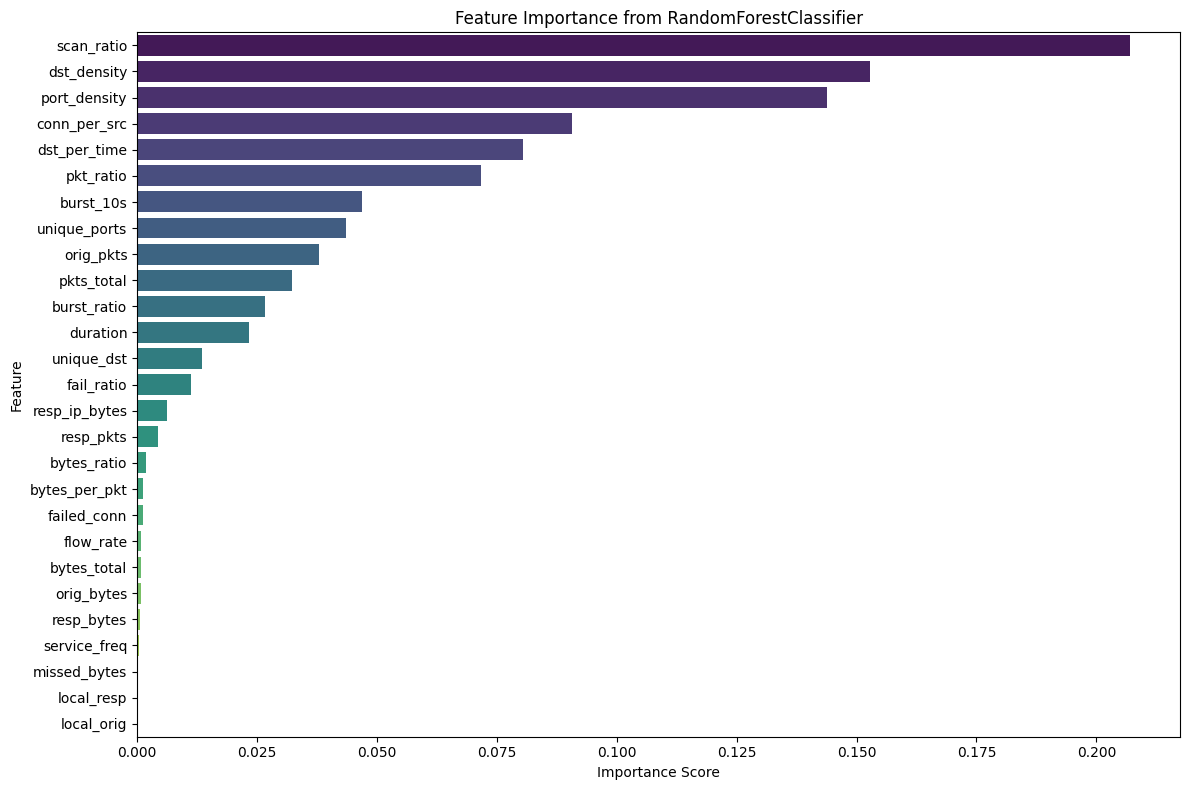

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_importances.values, y=sorted_importances.index, palette='viridis')
plt.title('Feature Importance from RandomForestClassifier')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [41]:
# Select the top N most important features (e.g., top 5)
sorted_importances = pd.read_csv('important_features.csv', index_col=0)
top_n_features = sorted_importances.head(8).index.to_list()

# Ensure 'label' is also included for further analysis
features_to_keep = top_n_features + ['label']
df_filtered = df_preprocessed[features_to_keep]

print("DataFrame filtered with the most important features:")
display(df_filtered.head())

DataFrame filtered with the most important features:


,scan_ratio,dst_density,port_density,conn_per_src,dst_per_time,pkt_ratio,burst_10s,unique_ports,label
0,0.066014,0.602491,0.066014,991061,22115.037037,3.0,26,65424,1
1,0.066014,0.602491,0.066014,991061,22115.037037,1.0,26,65424,1
2,0.066014,0.602491,0.066014,991061,22115.037037,1.0,26,65424,1
3,0.066014,0.602491,0.066014,991061,22115.037037,3.0,26,65424,1
4,0.066014,0.602491,0.066014,991061,22115.037037,1.0,26,65424,1


In [42]:
df_filtered.to_csv('filtered_data_concat.csv')

In [7]:
df_filtered = pd.read_csv('filtered_data_concat.csv', index_col=0)

In [9]:
df_filtered

,scan_ratio,dst_density,port_density,conn_per_src,dst_per_time,pkt_ratio,burst_10s,unique_ports,label
0,0.066014,0.602491,0.066014,991061,22115.037037,3.00,26,65424,1
1,0.066014,0.602491,0.066014,991061,22115.037037,1.00,26,65424,1
2,0.066014,0.602491,0.066014,991061,22115.037037,1.00,26,65424,1
3,0.066014,0.602491,0.066014,991061,22115.037037,3.00,26,65424,1
4,0.066014,0.602491,0.066014,991061,22115.037037,1.00,26,65424,1
...,...,...,...,...,...,...,...,...,...
4769019,0.000006,0.000020,0.000006,3602157,18.250000,1.00,3,20,1
4769020,0.000006,0.000020,0.000006,3602157,24.333333,1.25,2,20,1
4769021,0.000006,0.000020,0.000006,3602157,9.125000,1.00,7,20,0
4769022,0.000006,0.000020,0.000006,3602157,18.250000,1.00,3,20,0


In [8]:
X = df_filtered.drop('label', axis=1)
y = df_filtered['label']
rus = RandomUnderSampler(random_state=0)
X_resampled, y_resampled = rus.fit_resample(X, y)

## Training

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

# Initialize and train the RandomForestClassifier
rf_model_filtered = RandomForestClassifier(class_weight="balanced")
rf_model_filtered.fit(X_train, y_train)

# Make predictions on the test set
y_pred_filtered = rf_model_filtered.predict(X_test)

# Evaluate the model
print("RandomForestClassifier performance on filtered data:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_filtered):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_filtered))

## TRAINING LAMA!!!

RandomForestClassifier performance on filtered data:
Accuracy: 0.9430
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94    143415
           1       0.97      0.92      0.94    143511

    accuracy                           0.94    286926
   macro avg       0.94      0.94      0.94    286926
weighted avg       0.94      0.94      0.94    286926



In [11]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize and train the GradientBoostingClassifier
gbc_model_filtered = GradientBoostingClassifier(random_state=42)
gbc_model_filtered.fit(X_train, y_train)

# Make predictions on the test set
y_pred_gbc_filtered = gbc_model_filtered.predict(X_test)

# Evaluate the GradientBoostingClassifier model
print("\nGradientBoostingClassifier performance on filtered data:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gbc_filtered):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_gbc_filtered))


GradientBoostingClassifier performance on filtered data:
Accuracy: 0.9427
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94    143415
           1       0.97      0.92      0.94    143511

    accuracy                           0.94    286926
   macro avg       0.94      0.94      0.94    286926
weighted avg       0.94      0.94      0.94    286926



In [12]:
import pickle

# Save the model
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model_filtered, f)

    # Save the model
with open('gbc_model.pkl', 'wb') as f:
    pickle.dump(gbc_model_filtered, f)

## Testing

In [15]:
for filepath in glob.glob(os.path.join("./Malware", '*.test')):
    print(f"Loading log: {filepath}")
    df_test = parse_zeek_log(filepath)

df_test.to_csv('test_data.csv')

Loading log: ./Malware/conn-48-1.log.test


In [4]:
df_test = pd.read_csv('~/Documents/School/Enjiner/8/Senpro/iot-23/IoTScenarios/data/test_data.csv')

/tmp/ipykernel_17115/58711901.py:1: DtypeWarning: Columns (0: service) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv('~/Documents/School/Enjiner/8/Senpro/iot-23/IoTScenarios/data/test_data.csv')


In [8]:
df_test_processed = preprocess_data(df_test)

In [12]:
df_test_only = df_test.drop(columns=['label'])

In [13]:
df_test_only.to_csv('test_data.csv')

In [6]:
y_test = df_test_processed['label']
y_test

0          1
1          1
2          1
3          1
4          1
          ..
3394333    0
3394334    0
3394335    0
3394336    0
3394337    0
Name: label, Length: 3394338, dtype: category
Categories (2, int64): [0, 1]

In [7]:
X_test = df_test_processed.drop('label', axis=1)
X_test

,scan_ratio,dst_density,port_density,conn_per_src,dst_per_time,pkt_ratio,burst_10s,unique_ports
0,0.000001,0.496879,0.000001,3392003,280902.50,1.005780,5,4
1,0.000001,0.496879,0.000001,3392003,280902.50,1.005848,5,4
2,0.000001,0.496879,0.000001,3392003,280902.50,1.008130,5,4
3,0.000001,0.496879,0.000001,3392003,2247.22,1.007407,749,4
4,0.000001,0.496879,0.000001,3392003,2247.22,0.994152,749,4
...,...,...,...,...,...,...,...,...
3394333,0.500000,0.500000,0.500000,1,0.50,2.000000,1,1
3394334,0.500000,0.500000,0.500000,1,0.50,2.000000,1,1
3394335,0.500000,0.500000,0.500000,1,0.50,2.000000,1,1
3394336,0.500000,0.500000,0.500000,1,0.50,2.000000,1,1


In [25]:
# Load the model
with open('gbc_model.pkl', 'rb') as f:
    model = pickle.load(f)

In [26]:
y_pred = model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9427483044408663
              precision    recall  f1-score   support

           0       0.92      0.97      0.94    143415
           1       0.97      0.92      0.94    143511

    accuracy                           0.94    286926
   macro avg       0.94      0.94      0.94    286926
weighted avg       0.94      0.94      0.94    286926

[[138945   4470]
 [ 11957 131554]]
